In [59]:
# want to combine com and noncom cases into one workflow
# compare different values of a, define all lengths in terms of horizon radius
# will need to make two separate python scripts with the functions i will need to generate plots

In [60]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import shockFunc260331 as sf
import NCShockFunc260331 as nsf

In [61]:
num = 10000
sf.num = num
nsf.num = num

eps = 0.00001
sf.r0min = eps
sf.eps = eps
nsf.eps = eps

R = 1

In [62]:
r0grid = np.linspace(eps,R-eps,num)

calphagrid = sf.alpha(r0grid,R)
ncalphagrid = nsf.alpha(r0grid,R)

cmask = sf.k3(r0grid,R) > 0
ncmask = nsf.k3(r0grid,R) != 0

[]

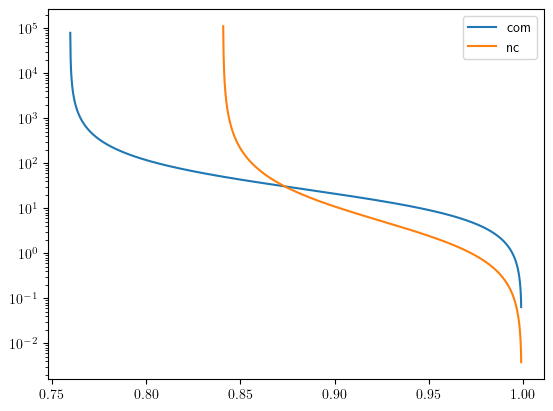

In [63]:
plt.plot(r0grid[cmask],calphagrid[cmask],label='com')
plt.plot(r0grid[ncmask],ncalphagrid[ncmask],label='nc')
plt.legend()
plt.semilogy()

In [64]:
normcalphagrid = calphagrid[cmask]/calphagrid[cmask].max()
normncalphagrid = ncalphagrid[ncmask]/ncalphagrid[ncmask].max()

[]

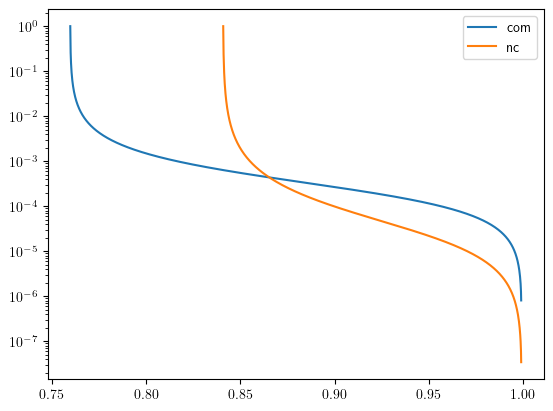

In [65]:
plt.plot(r0grid[cmask],normcalphagrid,label='com')
plt.plot(r0grid[ncmask],normncalphagrid,label='nc')
plt.legend()
plt.semilogy()

In [66]:
careaInt = sf.shockArea(r0grid,R)
ncareaInt = nsf.shockArea(r0grid,R)

cmask = careaInt > 0
ncmask = ncareaInt > 0

In [67]:
careaInt

array([0., 0., 0., ..., 0., 0., 0.], shape=(10000,))

(np.float64(0.0012899735854568443), np.float64(259.5461115206042))

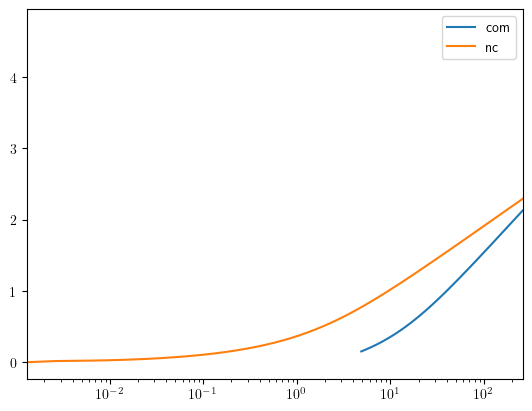

In [68]:
plt.plot(calphagrid[cmask],careaInt[cmask],label='com')
plt.plot(ncalphagrid[ncmask],ncareaInt[ncmask],label='nc')
plt.semilogx()
# plt.semilogy()
plt.legend()
plt.xlim((min(ncalphagrid[ncmask].min(),calphagrid[cmask].min()),min(ncalphagrid[ncmask].max(),calphagrid[cmask].max())))

In [96]:
rminarr = np.logspace(np.log10(R+eps),np.log10(min([sf.rmax,nsf.rmax])),num)

cLvsrminarr = sf.Lvsrmin(rminarr,R)
ncLvsrminarr = nsf.Lvsrmin(rminarr,R,0.25)
ncLvsrminarr2 = nsf.Lvsrmin(rminarr,R,0.05)
ncLvsrminarr3 = nsf.Lvsrmin(rminarr,R,0.5)

/Users/bkorotko03/Desktop/Holography/HoloProj/NCShockFunc260331.py:133: RuntimeWarning: divide by zero encountered in divide
  integ = 2/np.sqrt((rarr**4) * f(rarr,R) * h(rarr,a) * b(rarr,rmin))


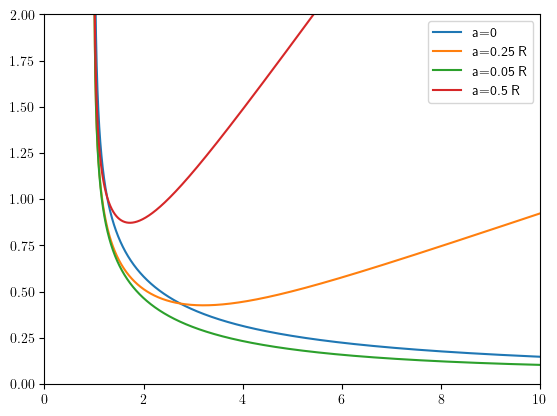

In [106]:
plt.plot(rminarr,cLvsrminarr,label='a=0')
plt.plot(rminarr,ncLvsrminarr,label='a=0.25 R')
plt.plot(rminarr,ncLvsrminarr2,label='a=0.05 R')
plt.plot(rminarr,ncLvsrminarr3,label='a=0.5 R')
plt.xlim((0,rminarr.max()/10))
plt.ylim((0,2))
# plt.semilogy()
plt.legend()

In [98]:
ncLvsrminarr3[:-500].min()

np.float64(0.8722374953832916)

In [99]:
adjrminarr = nsf.rMinCutoff(rminarr,ncLvsrminarr)
adjrminarr2 = nsf.rMinCutoff(rminarr,ncLvsrminarr2)
adjrminarr3 = nsf.rMinCutoff(rminarr,ncLvsrminarr3)

In [100]:
adjncLvsrminarr = nsf.Lvsrmin(adjrminarr,R,0.25)
adjncLvsrminarr2 = nsf.Lvsrmin(adjrminarr2,R,0.05)
adjncLvsrminarr3 = nsf.Lvsrmin(adjrminarr3,R,0.5)

In [101]:
cunArea = sf.unAreaInt(rminarr,R)
ncunArea = nsf.unAreaInt(adjrminarr,R,0.25)
ncunArea2 = nsf.unAreaInt(adjrminarr2,R,0.05)
ncunArea3 = nsf.unAreaInt(adjrminarr3,R,0.5)

(0.5, 2.0)

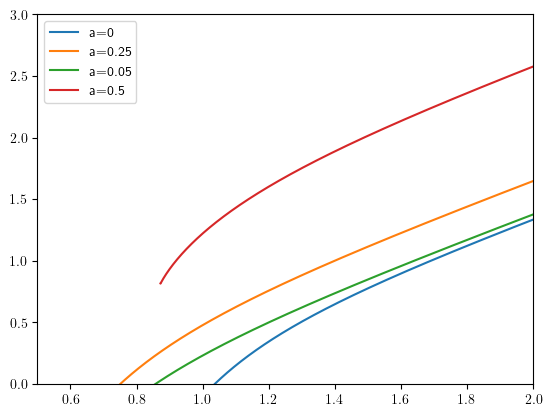

In [102]:
plt.plot(cLvsrminarr,cunArea,label='a=0')
plt.plot(adjncLvsrminarr,ncunArea,label='a=0.25')
plt.plot(adjncLvsrminarr2,ncunArea2,label='a=0.05')
plt.plot(adjncLvsrminarr3,ncunArea3,label='a=0.5')
plt.legend()
# plt.semilogy()
plt.ylim((0,3))
plt.xlim((0.5,2))